بسم الله

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
# import xgboost as xgb
# from tabulate import tabulate

# إعدادات العرض
sns.set(style='whitegrid', palette='muted', color_codes=True)
# النمذجة التنبؤية
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# تثبيت العشوائية
import random
random.seed(42)
np.random.seed(42)

# مكتبة الإحصاء والتحذيرات
import warnings
warnings.filterwarnings('ignore')
# محاولة القراءة بترميز مختلف

In [10]:
df = pd.read_csv("../Datasets/egypt_real_estate_listings.csv")

In [11]:
# add an 'id' column at the beginning (1..n)
if 'id' not in df.columns:
    df.insert(0, 'id', np.arange(1, len(df) + 1))
else:
    df['id'] = np.arange(1, len(df) + 1)
    df = df[['id'] + [c for c in df.columns if c != 'id']]

df.head()

,id,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,1,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,2,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,3,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,4,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,5,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"


In [12]:
df.tail()


,id,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
19919,19920,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,500,000",Code: 2404\nChalet for sale in North Edge Towe...,"North Edge Towers, New Alamein City, Al Alamei...",Chalet,"1,259 sqft / 117 sqm",2,2,21 Aug 2025,Cash,NaN
19920,19921,https://www.propertyfinder.eg/en/plp/buy/duple...,"24,000,000",Duplex for sale in Eastown -Sodic\n5th settlem...,"Eastown, 5th Settlement Compounds, The 5th Set...",Duplex,"2,756 sqft / 256 sqm",3+ Maid,4,1 Sep 2025,Cash,NaN
19921,19922,https://www.propertyfinder.eg/en/plp/buy/chale...,"3,000,000",Chalet for Sale in One of the Prime Projects o...,"White Sand, Markaz Al Hamam, North Coast",Chalet,"1,195 sqft / 111 sqm",2,2,30 Jul 2025,Cash,NaN
19922,19923,https://www.propertyfinder.eg/en/plp/buy/villa...,"9,500,000",Villa for sale in installments in Sarai Compou...,"Sarai, Mostakbal City Compounds, Mostakbal Cit...",Villa,"2,573 sqft / 239 sqm",5,4,23 Aug 2025,Cash,NaN
19923,19924,https://www.propertyfinder.eg/en/plp/buy/chale...,"7,500,000",Ground Chalet with Garden in Mountain View Nor...,"Mountain View, Qesm Ad Dabaah, North Coast",Chalet,990 sqft / 92 sqm,2,2,21 Aug 2025,Cash,NaN


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              19924 non-null  int64 
 1   url             19924 non-null  object
 2   price           19385 non-null  object
 3   description     19846 non-null  object
 4   location        19833 non-null  object
 5   type            19847 non-null  object
 6   size            19847 non-null  object
 7   bedrooms        19780 non-null  object
 8   bathrooms       19784 non-null  object
 9   available_from  19261 non-null  object
 10  payment_method  19383 non-null  object
 11  down_payment    5445 non-null   object
dtypes: int64(1), object(11)
memory usage: 1.8+ MB


In [14]:
df.dtypes


id                 int64
url               object
price             object
description       object
location          object
type              object
size              object
bedrooms          object
bathrooms         object
available_from    object
payment_method    object
down_payment      object
dtype: object

In [15]:
df.describe()


,id
count,19924.000000
mean,9962.500000
std,5751.707717
min,1.000000
25%,4981.750000
50%,9962.500000
75%,14943.250000
max,19924.000000


In [16]:
df.isnull().sum()


id                    0
url                   0
price               539
description          78
location             91
type                 77
size                 77
bedrooms            144
bathrooms           140
available_from      663
payment_method      541
down_payment      14479
dtype: int64

<Axes: >

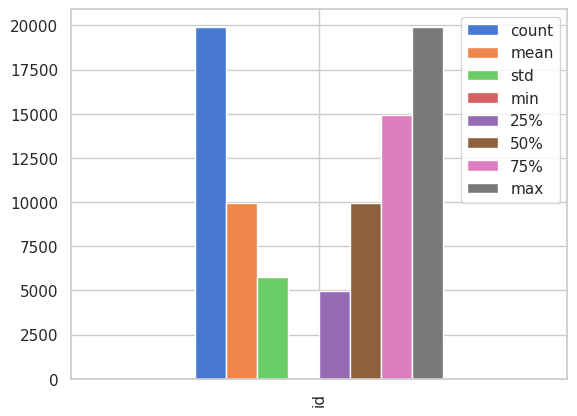

In [17]:
df.describe().T.plot(kind='bar')


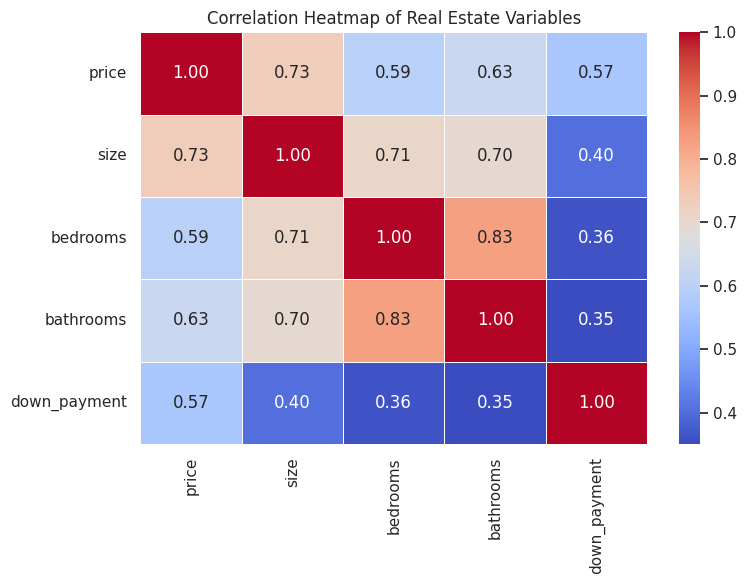

In [18]:
# Convert selected columns to numeric
numeric_columns = ['price', 'size', 'bedrooms', 'bathrooms', 'down_payment']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

# Drop rows with missing values
df_corr = df[numeric_columns].dropna()

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Real Estate Variables')
plt.tight_layout()
plt.show()


In [10]:
# for col in df:
#     if df[col].dtype == 'O':
#         sns.countplot(x=col,data=df)
#         plt.show()

In [19]:
df.dtypes


id                  int64
url                object
price             float64
description        object
location           object
type               object
size              float64
bedrooms          float64
bathrooms         float64
available_from     object
payment_method     object
down_payment      float64
dtype: object

In [20]:
# Create label encoders for categorical columns
label_encoders = {}
categorical_columns = ['location', 'type', 'payment_method']

# Create new DataFrame with encoded values
df_encoded = df.copy()

# Encode categorical columns
for col in categorical_columns:
    label_encoders[col] = LabelEncoder()
    # Fill NaN values with a placeholder before encoding
    df_encoded[col] = df_encoded[col].fillna('Unknown')
    df_encoded[col] = label_encoders[col].fit_transform(df_encoded[col])

# Convert available_from to numerical values (days from today)
# df_encoded['available_from'] = pd.to_datetime(df_encoded['available_from'], format='%d %b %Y', errors='coerce')
# df_encoded['days_until_available'] = (df_encoded['available_from'] - pd.Timestamp.now()).dt.days

# Drop original available_from column and any remaining null values
df_encoded.drop(['available_from', 'url', 'description'], axis=1, inplace=True)
df_encoded = df_encoded.dropna()

# Display the first few rows of the encoded dataset
print("Shape of encoded dataset:", df_encoded.shape)
df_encoded.head()

Shape of encoded dataset: (5248, 9)


,id,price,location,type,size,bedrooms,bathrooms,payment_method,down_payment
0,1,8000000.0,1346,4,732.0,1.0,1.0,0,1200000.0
1,2,25000000.0,785,15,2368.0,4.0,4.0,0,2100000.0
2,3,15135000.0,322,4,1270.0,2.0,2.0,0,1513000.0
3,4,12652000.0,1358,0,1787.0,3.0,2.0,1,1260000.0
4,5,45250000.0,653,15,4306.0,7.0,7.0,0,2262500.0


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_features = ['price', 'size', 'bedrooms', 'bathrooms', 'down_payment']
df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

In [14]:
from sklearn.neighbors import NearestNeighbors


nn_model = NearestNeighbors(metric='euclidean')
nn_model.fit(df_encoded)

NearestNeighbors(metric='euclidean')

In [15]:
def recommend_similar_houses(query_house_index, num_recommendations=5):
    distances, indices = nn_model.kneighbors(df_encoded.iloc[query_house_index].values.reshape(1, -1), n_neighbors=num_recommendations+1)
    recommended_indices = indices.squeeze()[1:]
    interested_house  =  df.iloc[[query_house_index]].dropna(axis=1)
    recommended_houses = df.iloc[recommended_indices]

    return interested_house, recommended_houses

In [16]:
query_house_index = 33  # Index of the query house in the dataframe
interested_house, recommended_houses = recommend_similar_houses(query_house_index)

In [17]:
print(f"Interested House:{interested_house}\n")


Interested House:                                                  url       price  \
33  https://www.propertyfinder.eg/en/plp/buy/villa...  25540000.0   

                                          description  \
33  Get your Villa in a prime location In Hear Of ...   

                                             location   type    size  \
33  Palm Hills New Cairo, 5th Settlement Compounds...  Villa  2799.0   

    bedrooms  bathrooms available_from payment_method  down_payment  
33       4.0        5.0     2 Sep 2025   Installments     1250000.0  



In [18]:
print(f"recommended_houses: \n {recommended_houses}")

recommended_houses: 
                                                     url       price  \
2800  https://www.propertyfinder.eg/en/plp/buy/villa...  15000000.0   
4525  https://www.propertyfinder.eg/en/plp/buy/apart...   5265000.0   
4360  https://www.propertyfinder.eg/en/plp/buy/apart...   3843000.0   
1957  https://www.propertyfinder.eg/en/plp/buy/villa...  50000000.0   
1245  https://www.propertyfinder.eg/en/plp/buy/villa...  27000000.0   

                                            description  \
2800  Get Your Property in NEW GOUNA with 0% Downpay...   
4525  Resale Apartment – Directly from Owner Prime L...   
4360  A fully finished two-bedroom apartment in Al M...   
1957  - Luxurious detached villa in Saada Compound i...   
1245  AZHA NORTH\n__________________________________...   

                                               location       type    size  \
2800   Makadi Orascom Resort, Makadi, Hurghada, Red Sea      Villa  1830.0   
4525  Taj City, 5th Settlement Compounds

In [19]:
interested_house

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
33,https://www.propertyfinder.eg/en/plp/buy/villa...,25540000.0,Get your Villa in a prime location In Hear Of ...,"Palm Hills New Cairo, 5th Settlement Compounds...",Villa,2799.0,4.0,5.0,2 Sep 2025,Installments,1250000.0


In [20]:
recommended_houses

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
2800,https://www.propertyfinder.eg/en/plp/buy/villa...,15000000.0,Get Your Property in NEW GOUNA with 0% Downpay...,"Makadi Orascom Resort, Makadi, Hurghada, Red Sea",Villa,1830.0,4.0,4.0,1 Sep 2025,Cash,NaN
4525,https://www.propertyfinder.eg/en/plp/buy/apart...,5265000.0,Resale Apartment – Directly from Owner Prime L...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,1238.0,2.0,2.0,26 Aug 2025,Installments,NaN
4360,https://www.propertyfinder.eg/en/plp/buy/apart...,3843000.0,A fully finished two-bedroom apartment in Al M...,"Al Maqsad, New Capital Compounds, New Capital ...",Apartment,1442.0,2.0,2.0,31 Aug 2025,Installments,192150.0
1957,https://www.propertyfinder.eg/en/plp/buy/villa...,50000000.0,- Luxurious detached villa in Saada Compound i...,"SAA'DA, The 1st Settlement, New Cairo City, Cairo",Villa,3821.0,3.0,3.0,2 Sep 2025,Cash,2500000.0
1245,https://www.propertyfinder.eg/en/plp/buy/villa...,27000000.0,AZHA NORTH\n__________________________________...,"Azha North, Ras Al Hekma, North Coast",Villa,4306.0,4.0,4.0,2 Sep 2025,Cash,NaN


In [22]:
import faiss

In [23]:
data = df_encoded.values.astype('float32')  # FAISS requires float32
dim = data.shape[1]

index = faiss.IndexFlatL2(dim)   # L2 distance
index.add(data)                  # add vectors

nlist = 100  # number of clusters
quantizer = faiss.IndexFlatL2(dim)
index = faiss.IndexIVFFlat(quantizer, dim, nlist)
index.train(data)
index.add(data)

In [24]:
def recommend_similar_houses(query_house_index, num_recommendations=5):
    query = data[query_house_index].reshape(1, -1)
    distances, indices = index.search(query, num_recommendations + 1)
    
    recommended_indices = indices[0][1:]  # skip first (same house)

    interested_house = df.iloc[[query_house_index]]
    recommended_houses = df.iloc[recommended_indices]

    return interested_house, recommended_houses

In [25]:
query_house_index = 33  # Index of the query house in the dataframe
interested_house, recommended_houses = recommend_similar_houses(query_house_index)

In [26]:
interested_house

,id,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
33,34,https://www.propertyfinder.eg/en/plp/buy/villa...,25540000.0,Get your Villa in a prime location In Hear Of ...,"Palm Hills New Cairo, 5th Settlement Compounds...",Villa,2799.0,4.0,5.0,2 Sep 2025,Installments,1250000.0


In [27]:
recommended_houses

,id,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
20,21,https://www.propertyfinder.eg/en/plp/buy/apart...,9000000.0,Area : New Heliopolis\nProject : Talala\nType:...,"Talala, New Heliopolis Compounds, New Heliopol...",Apartment,1345.0,3.0,3.0,2 Sep 2025,Installments,450000.0
17,18,https://www.propertyfinder.eg/en/plp/buy/chale...,29310000.0,Developer: Orascom\nProject: Makadi Heights\nU...,"Makadi Orascom Resort, Makadi, Hurghada, Red Sea",Chalet,1615.0,3.0,4.0,1 Sep 2025,Installments,11724000.0
14,15,https://www.propertyfinder.eg/en/plp/buy/apart...,3341100.0,Looking for elegant apartment with luxurious f...,"El Hadaba District, Hurghada, Red Sea",Apartment,797.0,1.0,1.0,30 Aug 2025,Cash,1002330.0
46,47,https://www.propertyfinder.eg/en/plp/buy/apart...,6000000.0,Own a 115 sqm Apartment with a Garden View in ...,"Madinaty, Cairo",Apartment,1238.0,3.0,2.0,2 Sep 2025,Installments,2900000.0
58,59,https://www.propertyfinder.eg/en/plp/buy/townh...,14815000.0,"IL Monte Galala – Ain Sokhna, between the moun...","IL Monte Galala, Al Ain Al Sokhna, Suez",Townhouse,1399.0,3.0,2.0,1 Sep 2025,Cash,740000.0
